## Basic Rotterdam-Antwerp trip  
This notebook shows the simple route without locks. There are two routes: Nieuwe Maas and Oude Maas. Some edges had to be removed or forces for these routes. The speed is fixed at 4m/s.

## 0. Import libraries

In [1]:
# packages used for creating and geo-locating the graph
import networkx as nx
import shapely

# packages related to the simulation (creating the vessel, running the simulation)
import datetime
import pickle
import simpy
import opentnsim
import opentnsim.fis as fis
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart
from opentnsim.lock.logutils import add_lock_chamber_dimensions_in_energy_eventtable
from opentnsim.graph.visualizations import plot_graph_folium
from opentnsim.graph.calculations import calculate_length_of_edge

# packages related to the locking module
from opentnsim.lock import lock as lock_module
from opentnsim.vessel_traffic_service import vessel_traffic_service as vessel_traffic_service_module

# packages related to the energy module 
from opentnsim.energy.logutils import (
    add_energy_attributes_to_eventtable,
    add_fuel_attributes_to_event_table,
    add_H2_attributes_to_event_table)

# packages needed for inspecting the output
import pandas as pd
import geopandas as gpd

# packages needed for plotting
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

# plot libraries
import folium

import numpy as np

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev47+gbe28de4fe.d20260122


In [2]:
%load_ext autoreload
%autoreload 2

## 0. Load useful methods 

### A) Network functions

In [3]:
# Method to remove edges  
def safe_remove_edge(G, u, v):
    if G.has_edge(u, v):
        G.remove_edge(u, v)
        G.remove_edge(v,u)
        print(f"Removed edge: {u} -> {v} (both directions)")
    else:
        print(f"Edge {u} -> {v} does not exist (already removed).")

In [4]:
# Method to find the closest node
def find_closest_node(G,point):
    distances, idx = nodes_gdf.sindex.nearest(point)
    # return nodes_gdf.iloc[idx[0]].name
    return nodes_gdf.iloc[idx[0]]

### 1. Define object classes

In [5]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        opentnsim.energy.mixins.ConsumesEnergy,
        lock_module.PassesLockComplex,             # allows to interact with a lock
        opentnsim.core.Identifiable,               # allows to give the object a name and a random ID,
        opentnsim.core.Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        opentnsim.core.ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        opentnsim.mixins.HasMultiDiGraph,           # allow to operate on a graph that can include parallel edges from and to the same nodes
        opentnsim.output.HasOutput,                # allow additional output to be stored
    ), 
    {}
)

In [6]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

### 2. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we use the Fairway Information System graph, and make the vessel sail from a container terminal at the Maasvlakte to the Kreekrak locks

#### 2.1 Load FIS graph

In [7]:
with open('FG_correct_distances_with_Volkerak_and_Kreekrak_Krammer_Hansweert.pickle', 'rb') as handle:
    FG = pickle.load(handle)
FG = FG.to_directed()

In [8]:
#plot_graph_folium(FG, 4, 50)

#### 2.2 Remove edges 
Edges need to be removed to ensure that the vessels sail representative routes.

### 2.2 Create water depth info on edges + visualize on network 

In this section, we are going to assign a water depth to each individual edge in the graph. At first, the water level (w.r.t. NAP) will be determined for each edge, based on data of waterinfo.nl (RWS). This data is based on a number of measuring points along the Rotterdam-Antwerp corridor.

In [9]:
# Remove Spui (very shallow waterway so most vessels are not able to pass this) 
safe_remove_edge(FG, 'S22992990_A', 'S22992990_B')

# Remove recreational bergediepsluis (not for IWT vessels) 
safe_remove_edge(FG, 'L51819_A', 'L51819_B')

# Remove recreational lock volkerak (not for IWT vessels) 
safe_remove_edge(FG, 'B46500_A', 'B46500_B')

# Remove Rietbaan in nieuwe Maas route (this edge creates a loop)
# TO DO: find out why this removes Noord instead of Rietbaan?? --> difference not so relevant though
safe_remove_edge(FG, '8863048', '8866570') 

# Remove edge at start of shallow SR part (around Noordplaat Island) 
safe_remove_edge(FG, "8862801", "8862255")

Removed edge: S22992990_A -> S22992990_B (both directions)
Removed edge: L51819_A -> L51819_B (both directions)
Removed edge: B46500_A -> B46500_B (both directions)
Removed edge: 8863048 -> 8866570 (both directions)
Removed edge: 8862801 -> 8862255 (both directions)


#### 2.3 Plan route 

In [10]:
maasvlakte     = shapely.Point(4.056694, 51.947162)
volkerak       = shapely.Point(4.409331, 51.690440)
kreekrak       = shapely.Point(4.228202, 51.461103)
meerhout       = shapely.Point(5.096662, 51.098779)
antwerp        = shapely.Point(4.344243, 51.279407)
botlek         = shapely.Point(4.315013, 51.894716)
erasmus_bridge = shapely.Point(4.486020, 51.908346)
krammer        = shapely.Point(4.160114, 51.661751)
hansweert      = shapely.Point(4.010556, 51.455824)
Noord1         = shapely.Point(4.622453,51.8854942)
Noord2         = shapely.Point(4.669784,51.8240557)
Scheldt_Rhine1 = shapely.Point(4.194823,51.6149341) 
Scheldt_Rhine2 = shapely.Point(4.220736,51.4943026)
antwerp_ZB     = shapely.Point(4.262775,51.3438188)
antwerp_SR     = shapely.Point(4.296340,51.3441803)
# Old values, too broad
# volkerak1      =shapely.Point(4.4544411, 51.6999594)
# volkerak2      =shapely.Point(4.3855190, 51.6756423)
# kreekrak1      =shapely.Point(4.2266464, 51.4668949)
# kreekrak2      =shapely.Point(4.2341995, 51.4304675)
# krammer1       =shapely.Point(4.1912842, 51.6615888)
# krammer2       =shapely.Point(4.1353655, 51.6608168)
# hansweert1     =shapely.Point(4.0063190, 51.4687396)
# hansweert2     =shapely.Point(4.0093231, 51.4374236)
# New more coordinates closer to start/end node
volkerak1      =shapely.Point(4.43615944214078, 51.7022764335403)
volkerak2      =shapely.Point(4.4077088440752465, 51.688733575668216)
kreekrak1      =shapely.Point(4.22794011751205, 51.4607863580163)
kreekrak2      =shapely.Point(4.231335107001528, 51.44661893151908)
krammer1       =shapely.Point(4.19134806597306, 51.66096215100399)
krammer2       =shapely.Point(4.1422864710351, 51.6610337843055)
hansweert1     =shapely.Point(4.005993986646047, 51.4692279083693)
hansweert2     =shapely.Point(4.0100974791618, 51.4541985999469)


In [11]:
nodes_gdf = gpd.GeoDataFrame(FG.nodes.values(), index=FG.nodes.keys())

In [12]:
# Find closest nodes for the locations
# Start locations
maasvlakte_node  = find_closest_node(FG,maasvlakte)
botlek_node      = find_closest_node(FG,botlek)
# Locks
volkerak_node   = find_closest_node(FG,volkerak)
kreekrak_node    = find_closest_node(FG,kreekrak)
krammer_node     = find_closest_node(FG,krammer)
hansweert_node   = find_closest_node(FG,hansweert)
# End locations
antwerp_node     = find_closest_node(FG,antwerp)
meerhout_node    = find_closest_node(FG,meerhout)
# Nieuwe maas route needs to pass the Erasmus bridge
erasmus_bridge_node      = find_closest_node(FG,erasmus_bridge)
# Shallow water start and end points
Noord1_node = find_closest_node(FG,Noord1)
Noord2_node = find_closest_node(FG,Noord2)
Scheldt_Rhine1_node = find_closest_node(FG,Scheldt_Rhine1)
Scheldt_Rhine2_node = find_closest_node(FG,Scheldt_Rhine2)
# End points
antwerp_ZB_node = find_closest_node(FG,antwerp_ZB)
antwerp_SR_node = find_closest_node(FG,antwerp_SR)
# Lock routes 
volkerak1_node= find_closest_node(FG,volkerak1)
volkerak2_node= find_closest_node(FG,volkerak2)
kreekrak1_node= find_closest_node(FG,kreekrak1)
kreekrak2_node= find_closest_node(FG,kreekrak2)
krammer1_node= find_closest_node(FG,krammer1)
krammer2_node= find_closest_node(FG,krammer2)
hansweert1_node= find_closest_node(FG,hansweert1)
hansweert2_node= find_closest_node(FG,hansweert2)

In [13]:
# Use network x to create the different routes
route_OM_SR = nx.shortest_path(FG, botlek_node.name, antwerp_SR_node.name, weight='length_m')

route_NM_SR = (
    nx.shortest_path(FG, botlek_node.name, erasmus_bridge_node.name, weight='length_m')
    + nx.shortest_path(FG, erasmus_bridge_node.name, antwerp_SR_node.name, weight='length_m')[1:])

route_OM_ZB = (
    nx.shortest_path(FG, botlek_node.name, hansweert_node.name, weight='length_m')
    + nx.shortest_path(FG, hansweert_node.name, antwerp_ZB_node.name, weight='length_m')[1:])

route_NM_ZB = (
    nx.shortest_path(FG, botlek_node.name, erasmus_bridge_node.name, weight='length_m')
    +nx.shortest_path(FG, erasmus_bridge_node.name, hansweert_node.name, weight='length_m')[1:]
    + nx.shortest_path(FG, hansweert_node.name, antwerp_ZB_node.name, weight='length_m')[1:])

shallow_NM = nx.shortest_path(FG, Noord1_node.name, Noord2_node.name, weight='length_m')
shallow_SR = nx.shortest_path(FG, Scheldt_Rhine1_node.name, Scheldt_Rhine2_node.name, weight='length_m')

route_volkerak = nx.shortest_path(FG, volkerak1_node.name, volkerak2_node.name, weight='length_m')
route_kreekrak = nx.shortest_path(FG, kreekrak1_node.name, kreekrak2_node.name, weight='length_m')
route_krammer = nx.shortest_path(FG, krammer1_node.name, krammer2_node.name, weight='length_m')
route_hansweert = nx.shortest_path(FG, hansweert1_node.name, hansweert2_node.name, weight='length_m')


In [14]:
shallow_NM_set = set(shallow_NM)
shallow_SR_set = set(shallow_SR)

for u, v in FG.edges():
    FG.edges[u, v]["GeneralDepth"] = 6
    # Reduce water depth for shallow parts of the route
    if u in shallow_NM_set or v in shallow_NM_set:
        FG.edges[u, v]["GeneralDepth"] = 4.3
    if u in shallow_SR_set or v in shallow_SR_set:
        FG.edges[u, v]["GeneralDepth"] = 4.3

### 3. Run simulation
##### 3.1 Set mission and simpy environment with VTS

In [15]:
# start simpy environment
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start
env.graph = FG
env.graph.crs_m = 'EPSG:28992'

# add components important for locking to the environment
env.vessel_traffic_service = vessel_traffic_service_module.VesselTrafficService(graph=FG, crs_m = "EPSG:28992") #Amersfoort / RD New reference system

In [16]:
data_vessel_1 = {
    "env": env,
    "name": 'M8 loaded passing Volkerak',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,        #
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_volkerak[0]]['geometry'],
    "route": route_volkerak,             # the route to sail
}  # 

data_vessel_2 = {
    "env": env,
    "name": 'M8 loaded passing Kreekrak',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,        #
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 2, 0, 0, 0),
    "geometry": env.graph.nodes[route_kreekrak[0]]['geometry'],
    "route": route_kreekrak,             # the route to sail
}  # 

data_vessel_3 = {
    "env": env,
    "name": 'M8 loaded passing Krammer',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,        #
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 3, 0, 0, 0),
    "geometry": env.graph.nodes[route_krammer[0]]['geometry'],
    "route": route_krammer,             # the route to sail
}  # 

data_vessel_4 = {
    "env": env,
    "name": 'M8 loaded passing Hansweert',           # you can give the vessel an arbitratry name
    "type": 'P_tot_given=P_installed', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_tot_given": 1750.0*0.35,        #
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 4, 0, 0, 0),
    "geometry": env.graph.nodes[route_hansweert[0]]['geometry'],
    "route": route_hansweert,             # the route to sail
}  # 

# create an instance of the Vessel class using the input dict data_vessel
vessel_1 = Vessel(**data_vessel_1)
vessel_2 = Vessel(**data_vessel_2)
vessel_3 = Vessel(**data_vessel_3)
vessel_4 = Vessel(**data_vessel_4)

# env.process(mission(env, vessel_1))
# env.process(mission(env, vessel_2))
# env.process(mission(env, vessel_3))
# env.process(mission(env, vessel_4))


##### 3.2 Create lock objects

In [17]:
with open('Volkerak_information.pickle', 'rb') as handle:
    information_Volkerak = pickle.load(handle)

In [18]:
Volkerak = lock_module.IsLockComplex(
    env = env,
    name = 'Volkerak',
    node_open = information_Volkerak["lock_node_A"],
    node_A = information_Volkerak["lock_node_A"],
    node_B = information_Volkerak["lock_node_B"],
    edge_waiting_area_A = information_Volkerak["edge_waiting_area_A"], 
    edge_waiting_area_B = information_Volkerak["edge_waiting_area_B"],
    distance_lock_doors_A_to_waiting_area_A = 480., #information_Volkerak["distance_lock_doors_A_to_waiting_area_A"], #
    distance_lock_doors_B_to_waiting_area_B = 260., #information_Volkerak["distance_lock_doors_B_to_waiting_area_B"], #
    distance_from_start_node_to_lock_doors_A = information_Volkerak["distance_from_start_node_to_lock_doors_A"],
    distance_from_end_node_to_lock_doors_B = information_Volkerak["distance_from_end_node_to_lock_doors_B"],
    lock_length = information_Volkerak["lock_length"],
    lock_width = information_Volkerak["lock_width"],
    lock_depth = information_Volkerak["lock_depth"],
    levelling_time = 562, #545, #700,
    # levelling_time = 577, #AG
    sailing_distance_to_crossing_point = 260, #300.
    doors_opening_time= 100,
    doors_closing_time= 100,
    speed_reduction_length_before_waiting_area = 600,
    sailing_out_speed_A = 1.5,
    sailing_out_speed_B = 1.5,
    speed_reduction_factor = 0.5,
    speed_reduction_factor_waiting_area_A = 0.5,
    speed_reduction_factor_waiting_area_B = 0.5,
    # mandatory_waiting_time_before_lock = 298, #531, #900,
    # mandatory_waiting_time_before_lock = 257, #AVG
    mandatory_waiting_time_before_lock = 0,
    registration_nodes = [information_Volkerak["node_A"], information_Volkerak["node_B"]],
    P_berthing_perc = 0.20,
    P_berthed_perc = 0.05,
    P_deberthing_perc = 0.20,
)

In [19]:
with open('Kreekrak_information.pickle', 'rb') as handle:
    information_Kreekrak = pickle.load(handle)

In [20]:
Kreekrak = lock_module.IsLockComplex(
    env = env,
    name = 'Kreekrak',
    node_open = information_Kreekrak["lock_node_A"],
    node_A = information_Kreekrak["lock_node_A"],
    node_B = information_Kreekrak["lock_node_B"],
    edge_waiting_area_A = information_Kreekrak["edge_waiting_area_A"], 
    edge_waiting_area_B = information_Kreekrak["edge_waiting_area_B"],
    distance_lock_doors_A_to_waiting_area_A = 300., #information_Kreekrak["distance_lock_doors_A_to_waiting_area_A"], #
    distance_lock_doors_B_to_waiting_area_B = 300., #information_Kreekrak["distance_lock_doors_B_to_waiting_area_B"], #
    distance_from_start_node_to_lock_doors_A = information_Kreekrak["distance_from_start_node_to_lock_doors_A"],
    distance_from_end_node_to_lock_doors_B = information_Kreekrak["distance_from_end_node_to_lock_doors_B"],
    lock_length = information_Kreekrak["lock_length"],
    lock_width = information_Kreekrak["lock_width"],
    lock_depth = information_Kreekrak["lock_depth"],
    levelling_time = 603, #586, #500,
    # levelling_time = 606, #AVG
    sailing_distance_to_crossing_point = 300,
    doors_opening_time= 100,
    doors_closing_time= 100,
    speed_reduction_length_before_waiting_area = 600,
    sailing_out_speed_A = 1.5,
    sailing_out_speed_B = 1.5,
    speed_reduction_factor = 0.5,
    speed_reduction_factor_waiting_area_A = 0.5,
    speed_reduction_factor_waiting_area_B = 0.5,
    # mandatory_waiting_time_before_lock = 408+150, #675, #900,
    # mandatory_waiting_time_before_lock = 511+150, #AVG
    mandatory_waiting_time_before_lock = 150,
    registration_nodes = ['8868181', information_Kreekrak["node_B"]], #information_Kreekrak["node_A"]
    P_berthing_perc = 0.20,
    P_berthed_perc = 0.05,
    P_deberthing_perc = 0.20,
)

In [21]:
with open('Krammer_information.pickle', 'rb') as handle:
    information_Krammer = pickle.load(handle)

In [22]:
Krammer = lock_module.IsLockComplex(
    env = env,
    name = 'Krammer',
    node_open = information_Krammer["lock_node_A"],
    node_A = information_Krammer["lock_node_A"],
    node_B = information_Krammer["lock_node_B"],
    edge_waiting_area_A = information_Krammer["edge_waiting_area_A"], 
    edge_waiting_area_B = (information_Krammer["edge_waiting_area_B"][1],information_Krammer["edge_waiting_area_B"][0]),
    distance_lock_doors_A_to_waiting_area_A = 300., #information_Krammer["distance_lock_doors_A_to_waiting_area_A"], #
    distance_lock_doors_B_to_waiting_area_B = 300., # information_Krammer["distance_lock_doors_B_to_waiting_area_B"], #
    distance_from_start_node_to_lock_doors_A = information_Krammer["distance_from_end_node_to_lock_doors_B"],
    distance_from_end_node_to_lock_doors_B = information_Krammer["distance_from_start_node_to_lock_doors_A"],
    lock_length = information_Krammer["lock_length"],
    lock_width = information_Krammer["lock_width"],
    lock_depth = information_Krammer["lock_depth"],
    levelling_time = 898, #881, #500,
    # levelling_time = 643, #AVG
    sailing_distance_to_crossing_point = 300,
    doors_opening_time= 100,
    doors_closing_time= 100,
    speed_reduction_length_before_waiting_area = 600,
    sailing_out_speed_A = 1.5,
    sailing_out_speed_B = 1.5,
    speed_reduction_factor = 0.5,
    speed_reduction_factor_waiting_area_A = 0.5,
    speed_reduction_factor_waiting_area_B = 0.5,
    # mandatory_waiting_time_before_lock = 638, #881, #900,
    # mandatory_waiting_time_before_lock = 310, #AVG
    mandatory_waiting_time_before_lock = 0,
    registration_nodes = [information_Krammer["node_A"], information_Krammer["node_B"]],
    P_berthing_perc = 0.20,
    P_berthed_perc = 0.05,
    P_deberthing_perc = 0.20,
)

In [23]:
with open('Hansweert_information.pickle', 'rb') as handle:
    information_Hansweert = pickle.load(handle)

In [24]:
Hansweert = lock_module.IsLockComplex(
    env = env,
    name = 'Hansweert',
    node_open = information_Hansweert["lock_node_A"],
    node_A = information_Hansweert["lock_node_A"],
    node_B = information_Hansweert["lock_node_B"],
    edge_waiting_area_A = information_Hansweert["edge_waiting_area_A"], 
    edge_waiting_area_B = information_Hansweert["edge_waiting_area_B"],
    distance_lock_doors_A_to_waiting_area_A = information_Hansweert["distance_lock_doors_A_to_waiting_area_A"],
    distance_lock_doors_B_to_waiting_area_B = information_Hansweert["distance_lock_doors_B_to_waiting_area_B"],
    distance_from_start_node_to_lock_doors_A = information_Hansweert["distance_from_start_node_to_lock_doors_A"],
    distance_from_end_node_to_lock_doors_B = information_Hansweert["distance_from_end_node_to_lock_doors_B"],
    lock_length = information_Hansweert["lock_length"],
    lock_width = information_Hansweert["lock_width"],
    lock_depth = information_Hansweert["lock_depth"],
    levelling_time = 399, #382, #500,
    # levelling_time = 636, #AVG
    sailing_distance_to_crossing_point = 300,
    doors_opening_time= 100,
    doors_closing_time= 100,
    speed_reduction_length_before_waiting_area = 600,
    sailing_out_speed_A = 1.5,
    sailing_out_speed_B = 1.5,
    speed_reduction_factor = 0.5,
    speed_reduction_factor_waiting_area_A = 0.5,
    speed_reduction_factor_waiting_area_B = 0.5,
    # mandatory_waiting_time_before_lock = 220+150, #576, #900,
    # mandatory_waiting_time_before_lock = 485+150, #AVG
    mandatory_waiting_time_before_lock = 150,
    registration_nodes = [information_Hansweert["node_A"], information_Hansweert["node_B"]],
    P_berthing_perc = 0.20,
    P_berthed_perc = 0.05,
    P_deberthing_perc = 0.20,
)

In [25]:
# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2))
env.process(mission(env, vessel_3))
env.process(mission(env, vessel_4))

env.run()

C:\Users\929509\OpenTNSim\opentnsim\lock\lock.py:1908: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\929509\OpenTNSim\opentnsim\lock\lock.py:1908: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



#### Volkerak time-distance plots

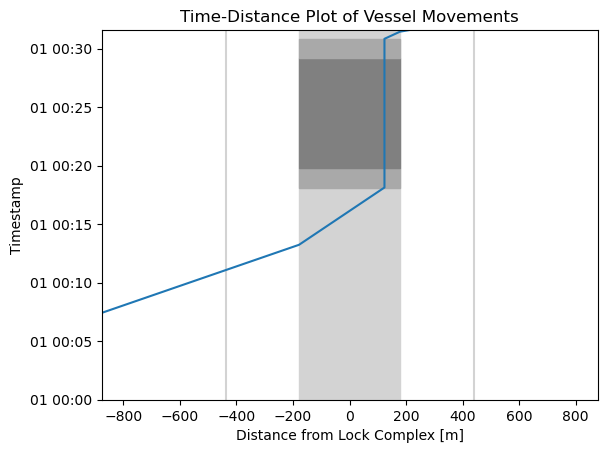

In [26]:
fig = Volkerak.create_time_distance_plot(vessels = [vessel_1])
fig

#### Kreekrak time-distance plots

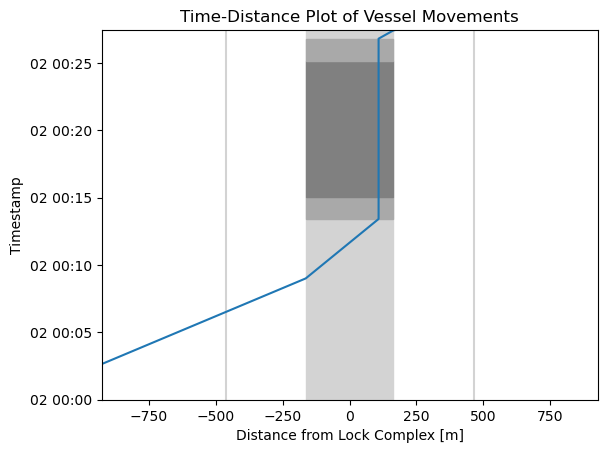

In [27]:
fig = Kreekrak.create_time_distance_plot(vessels = [vessel_2])
fig

#### Krammer time-distance plots

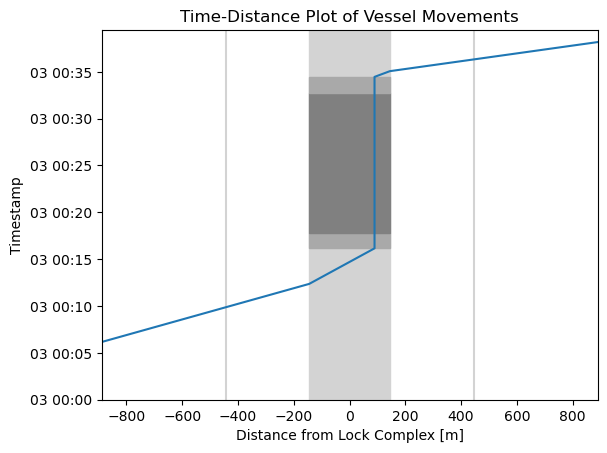

In [28]:
fig = Krammer.create_time_distance_plot(vessels = [vessel_3])
fig

#### Hansweert time-distance plots

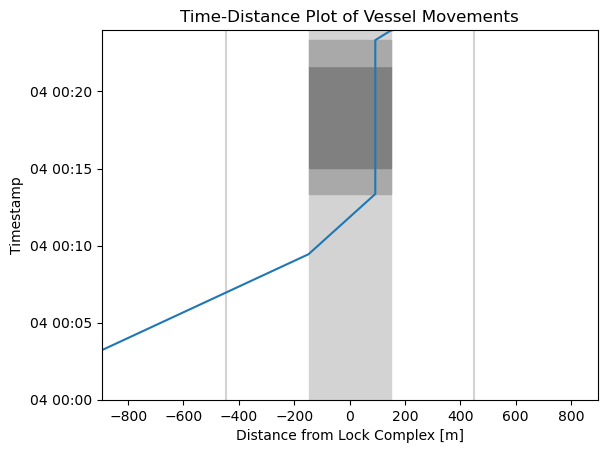

In [29]:
fig = Hansweert.create_time_distance_plot(
    vessels = [vessel_4], 
)
fig

### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [30]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

pd.set_option('display.max_rows', None)
display(df)

'M8 loaded passing Volkerak' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 8860743 to node 8862498 start,2024-01-01 00:00:00.000000,0,POINT (4.43615944214078 51.7022764335403)
1,Sailing to waiting area start,2024-01-01 00:00:00.000000,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.43615944214078 51.7022764335403)
2,Sailing to waiting area stop,2024-01-01 00:01:59.152925,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.430275043637441 51.700044229836266)
3,Sailing from node 8860743 to node 8862498 stop,2024-01-01 00:01:59.152925,0.0,POINT (4.43027504290525 51.7000442261129)
4,Sailing from node 8862498 to node B34113_A start,2024-01-01 00:01:59.152925,0.0,POINT (4.43027504290525 51.7000442261129)
5,Sailing to waiting area start,2024-01-01 00:01:59.152925,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.43027504290525 51.7000442261129)
6,Sailing to waiting area stop,2024-01-01 00:04:14.007755,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.423763691624531 51.69737292560266)
7,Sailing to waiting area (with reduced speed) s...,2024-01-01 00:04:14.007755,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.423763691624531 51.69737292560266)
8,Sailing to waiting area (with reduced speed) stop,2024-01-01 00:09:14.007755,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.417208372763805 51.69384273466657)
9,Sailing to first lock doors start,2024-01-01 00:09:14.007755,"{'origin': '', 'destination': '', 'route': [],...",POINT (4.417208372763805 51.69384273466657)


The inspection of the logbook data shows that Vessel moved from its origin (*Node 0*) to its destination (*Node 1*). The print statements show that the length of the route from *Node 0* to *Node 1* is exactly 100 km. At a given speed of 1 m/s the trip duration should be exactly 100000 seconds, as is indeed shown to be the case.

In [31]:
# df_eventtable = logbook2eventtable([vessel_1])
df_eventtable = logbook2eventtable([vessel_1, vessel_2, vessel_3, vessel_4])
df_eventtable

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s)
0,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8860743 to node 8862498,Sailing to waiting area,POINT (4.43615944214078 51.7022764335403),POINT (4.430275043637441 51.700044229836266),2024-01-01 00:00:00.000000,2024-01-01 00:01:59.152925,476.611439,119.152925
1,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to waiting area,POINT (4.43027504290525 51.7000442261129),POINT (4.423763691624531 51.69737292560266),2024-01-01 00:01:59.152925,2024-01-01 00:04:14.007755,539.419052,134.854830
2,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to waiting area (with reduced speed),POINT (4.423763691624531 51.69737292560266),POINT (4.417208372763805 51.69384273466657),2024-01-01 00:04:14.007755,2024-01-01 00:09:14.007755,599.999960,300.000000
3,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to first lock doors,POINT (4.417208372763805 51.69384273466657),POINT (4.411964025200449 51.691016098663965),2024-01-01 00:09:14.007755,2024-01-01 00:13:14.007755,480.000004,240.000000
4,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to position in lock,POINT (4.411964025200449 51.691016098663965),POINT (4.408656280617491 51.68924219105196),2024-01-01 00:13:14.007755,2024-01-01 00:18:07.626980,302.101556,293.619225
5,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Waiting for lock gate closing,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2024-01-01 00:18:07.626980,2024-01-01 00:19:47.626980,0.000000,100.000000
6,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Waiting for lock levelling,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2024-01-01 00:19:47.626980,2024-01-01 00:29:09.626980,0.000000,562.000000
7,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Waiting for lock gate opening,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2024-01-01 00:29:09.626980,2024-01-01 00:30:49.626980,0.000000,100.000000
8,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to second lock doors,POINT (4.408656280617491 51.68924219105196),POINT (4.408054344012045 51.68891905583165),2024-01-01 00:30:49.626980,2024-01-01 00:31:26.293646,55.000000,36.666666
9,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to lock complex exit,POINT (4.408054344012045 51.68891905583165),POINT (4.4077088440752465 51.688733575668216),2024-01-01 00:31:26.293646,2024-01-01 00:31:34.185952,31.569531,7.892306


In [32]:
def aggregate_main_activities(df):
    df = df.copy()

    # Ensure datetime
    df['start time'] = pd.to_datetime(df['start time'])
    df['stop time'] = pd.to_datetime(df['stop time'])

    # 1. Create consecutive groups
    df['group'] = (
        df['main activity name'] != df['main activity name'].shift()
    ).cumsum()

    # 2. Aggregate
    result = (
        df.groupby('group')
        .agg({
            'main activity name': 'first',   # <-- explicitly kept
            'start time': 'min',
            'stop time': 'max',
            'distance (m)': 'sum',
            'duration (s)': 'sum',
            'start location': 'first',
            'stop location': 'last'
        })
        .reset_index(drop=True)
    )

    # 3. Add message column (same as main activity)
    result['message'] = result['main activity name']

    return result

import re

def extract_edge(message):
    pattern = r'from node (\S+) to node (\S+)'
    match = re.search(pattern, message)
    
    if match:
        from_node, to_node = match.groups()
        return from_node, to_node
    return None, None

def get_length(row, graph):
    try:
        return graph.edges[row['from_node'], row['to_node']]['length_m']
    except Exception:
        return np.nan

In [33]:
df_eventtable_agg = aggregate_main_activities(df_eventtable)

In [34]:
df_eventtable_agg[['from_node', 'to_node']] = df_eventtable_agg['main activity name'].apply(
    lambda x: pd.Series(extract_edge(x))
)

df_eventtable_agg['length_m'] = df_eventtable_agg.apply(
    lambda x: get_length(x, env.graph),
    axis=1
)

In [35]:
# add energy attributes to the minimum event table
df_eventtable_energy = add_energy_attributes_to_eventtable(df_eventtable, [vessel_1, vessel_2, vessel_3, vessel_4])        
df_eventtable_energy = add_lock_chamber_dimensions_in_energy_eventtable(df_eventtable_energy, env)
# pd.set_option('display.max_columns', None)
df_eventtable_energy

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),velocity (m/s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh)
0,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8860743 to node 8862498,Sailing to waiting area,POINT (4.43615944214078 51.7022764335403),POINT (4.430275043637441 51.700044229836266),2024-01-01 00:00:00.000000,2024-01-01 00:01:59.152925,476.611439,119.152925,3.999998,6.0,None,0.0,619.442833,619.442833,1750.0,20.502340
1,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to waiting area,POINT (4.43027504290525 51.7000442261129),POINT (4.423763691624531 51.69737292560266),2024-01-01 00:01:59.152925,2024-01-01 00:04:14.007755,539.419052,134.854830,3.999998,6.0,None,0.0,619.442937,619.442937,1750.0,23.204131
2,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to waiting area (with reduced speed),POINT (4.423763691624531 51.69737292560266),POINT (4.417208372763805 51.69384273466657),2024-01-01 00:04:14.007755,2024-01-01 00:09:14.007755,599.999960,300.000000,2.000000,6.0,None,0.0,153.547302,153.547302,1750.0,12.795609
3,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to first lock doors,POINT (4.417208372763805 51.69384273466657),POINT (4.411964025200449 51.691016098663965),2024-01-01 00:09:14.007755,2024-01-01 00:13:14.007755,480.000004,240.000000,2.000000,6.0,None,0.0,153.547317,153.547317,1750.0,10.236488
4,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to position in lock,POINT (4.411964025200449 51.691016098663965),POINT (4.408656280617491 51.68924219105196),2024-01-01 00:13:14.007755,2024-01-01 00:18:07.626980,302.101556,293.619225,1.028889,6.0,None,0.0,97.215255,97.215255,1750.0,7.928963
5,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Waiting for lock gate closing,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2024-01-01 00:18:07.626980,2024-01-01 00:19:47.626980,0.000000,100.000000,0.000000,6.0,None,0.0,350.000000,350.000000,1750.0,9.722222
6,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Waiting for lock levelling,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2024-01-01 00:19:47.626980,2024-01-01 00:29:09.626980,0.000000,562.000000,0.000000,6.0,None,0.0,87.500000,87.500000,1750.0,13.659722
7,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Waiting for lock gate opening,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2024-01-01 00:29:09.626980,2024-01-01 00:30:49.626980,0.000000,100.000000,0.000000,6.0,None,0.0,350.000000,350.000000,1750.0,9.722222
8,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to second lock doors,POINT (4.408656280617491 51.68924219105196),POINT (4.408054344012045 51.68891905583165),2024-01-01 00:30:49.626980,2024-01-01 00:31:26.293646,55.000000,36.666666,1.500000,6.0,None,0.0,116.292305,116.292305,1750.0,1.184459
9,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to lock complex exit,POINT (4.408054344012045 51.68891905583165),POINT (4.4077088440752465 51.688733575668216),2024-01-01 00:31:26.293646,2024-01-01 00:31:34.185952,31.569531,7.892306,4.000039,6.0,None,0.0,619.463799,619.463799,1750.0,1.358055


In [36]:
# add fuel attributes to the minimum event table with energy attributes
# df_eventtable_energy_fuel = add_fuel_attributes_to_event_table(df_eventtable_energy, [vessel_1, vessel_2, vessel_3, vessel_4])

# pd.set_option('display.max_columns', None)
# df_eventtable_energy_fuel

In [37]:
# Trying to include the new H2 table
# add H2 attributes to the minimum event table with energy attributes
df_eventtable_energy_H2 = add_H2_attributes_to_event_table(df_eventtable_energy, [vessel_1, vessel_2, vessel_3, vessel_4])

pd.set_option('display.max_columns', None)
df_eventtable_energy_H2

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),velocity (m/s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),H2_consumption (g),H2_consumption_m (g/m),H2_consumption_s (g/s)
0,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8860743 to node 8862498,Sailing to waiting area,POINT (4.43615944214078 51.7022764335403),POINT (4.430275043637441 51.700044229836266),2024-01-01 00:00:00.000000,2024-01-01 00:01:59.152925,476.611439,119.152925,3.999998,6.0,None,0.0,619.442833,619.442833,1750.0,20.502340,1413.592180,2.965922,11.863680
1,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to waiting area,POINT (4.43027504290525 51.7000442261129),POINT (4.423763691624531 51.69737292560266),2024-01-01 00:01:59.152925,2024-01-01 00:04:14.007755,539.419052,134.854830,3.999998,6.0,None,0.0,619.442937,619.442937,1750.0,23.204131,1599.874825,2.965922,11.863682
2,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to waiting area (with reduced speed),POINT (4.423763691624531 51.69737292560266),POINT (4.417208372763805 51.69384273466657),2024-01-01 00:04:14.007755,2024-01-01 00:09:14.007755,599.999960,300.000000,2.000000,6.0,None,0.0,153.547302,153.547302,1750.0,12.795609,882.229627,1.470383,2.940765
3,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to first lock doors,POINT (4.417208372763805 51.69384273466657),POINT (4.411964025200449 51.691016098663965),2024-01-01 00:09:14.007755,2024-01-01 00:13:14.007755,480.000004,240.000000,2.000000,6.0,None,0.0,153.547317,153.547317,1750.0,10.236488,705.783768,1.470383,2.940766
4,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to position in lock,POINT (4.411964025200449 51.691016098663965),POINT (4.408656280617491 51.68924219105196),2024-01-01 00:13:14.007755,2024-01-01 00:18:07.626980,302.101556,293.619225,1.028889,6.0,None,0.0,97.215255,97.215255,1750.0,7.928963,546.684930,1.809606,1.861884
5,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Waiting for lock gate closing,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2024-01-01 00:18:07.626980,2024-01-01 00:19:47.626980,0.000000,100.000000,0.000000,6.0,None,0.0,350.000000,350.000000,1750.0,9.722222,670.326267,0.000000,6.703263
6,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Waiting for lock levelling,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2024-01-01 00:19:47.626980,2024-01-01 00:29:09.626980,0.000000,562.000000,0.000000,6.0,None,0.0,87.500000,87.500000,1750.0,13.659722,941.808405,0.000000,1.675816
7,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Waiting for lock gate opening,POINT (4.408656280617491 51.68924219105196),POINT (4.408656280617491 51.68924219105196),2024-01-01 00:29:09.626980,2024-01-01 00:30:49.626980,0.000000,100.000000,0.000000,6.0,None,0.0,350.000000,350.000000,1750.0,9.722222,670.326267,0.000000,6.703263
8,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to second lock doors,POINT (4.408656280617491 51.68924219105196),POINT (4.408054344012045 51.68891905583165),2024-01-01 00:30:49.626980,2024-01-01 00:31:26.293646,55.000000,36.666666,1.500000,6.0,None,0.0,116.292305,116.292305,1750.0,1.184459,81.665870,1.484834,2.227251
9,354fbf67-31ca-4786-b3c0-89106dd2dd4e,M8 loaded passing Volkerak,Sailing from node 8862498 to node B34113_A,Sailing to lock complex exit,POINT (4.4080543440120

### Lock plots 

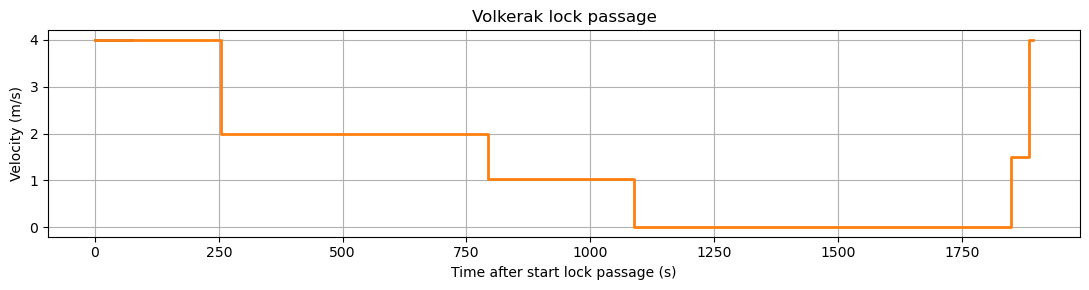

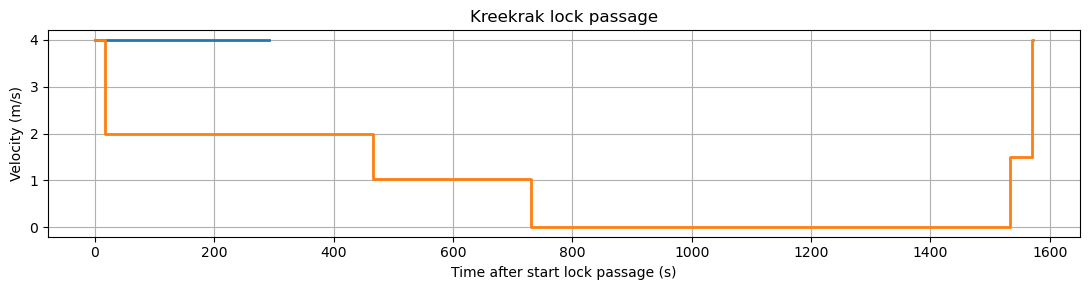

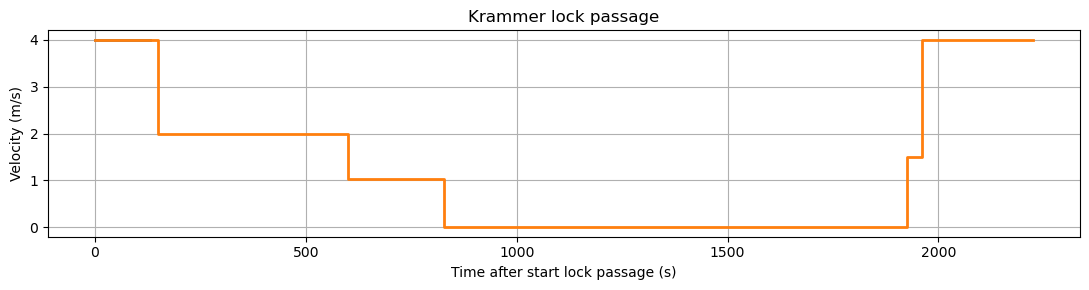

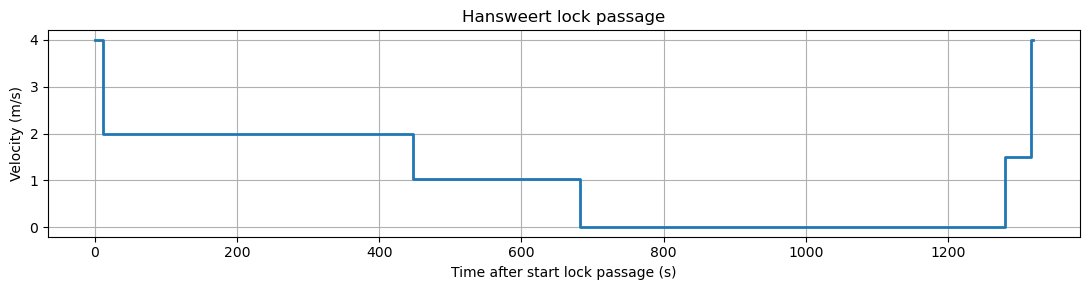

In [46]:
df_all = df_eventtable_energy_H2.copy()
df_all = df_all.sort_values("start time").reset_index(drop=True)

# CHANGE LOCK ROWS
lock_rows = {
    "Volkerak":  (0, 10),
    "Kreekrak":  (11, 23),
    "Krammer":   (23, 36),
    "Hansweert": (36, 52),
}

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for lock_name, (row_start, row_end) in lock_rows.items():

    # rows belonging to this lock
    df_lock = df_all.iloc[row_start:row_end + 1].copy()

    # # Keep only LOADED vessels on relevant routes
    # df_lock = df_lock[
    #     df_lock["object name"].str.contains(" loaded", na=False) &
    #     (
    #         df_lock["object name"].str.contains("OM\\+ZB", na=False) |
    #         df_lock["object name"].str.contains("OM\\+SR", na=False)
    #     )
    # ]

    # # Only 1 plot for volkerak
    # if lock_name == "Volkerak":
    #     df_lock = df_lock[
    #         df_lock["object name"].str.contains("OM\\+SR", na=False)
    #     ]
    #     one_object_id = df_lock["object id"].iloc[0]
    #     df_lock = df_lock[df_lock["object id"] == one_object_id]

#     # Plots
    # fig, (ax_v, ax_p) = plt.subplots(
    fig, (ax_v) = plt.subplots(
        # 2, 1, figsize=(11, 5), sharex=True
        1, 1, figsize=(11, 3), sharex=True
    )

    for i, (route, g) in enumerate(df_lock.groupby("object name")):

        g = g.sort_values("start time").copy()

        t_start = g["duration (s)"].cumsum().shift(fill_value=0)
        t_end   = t_start + g["duration (s)"]

        t_plot = np.column_stack([t_start, t_end]).ravel()
        v_plot = np.repeat(g["velocity (m/s)"].values, 2)
        p_plot = np.repeat(g["P_given (kW)"].values, 2)

        color = base_colors[i % len(base_colors)]

        # Velocity
        ax_v.plot(
            t_plot,
            v_plot,
            drawstyle="steps-post",
            linewidth=2,
            color=color,
            # label=route
        )

        # Power
        # ax_p.plot(
        #     t_plot,
        #     p_plot,
        #     drawstyle="steps-post",
        #     # linestyle="--",
        #     linewidth=2,
        #     color=color,
        #     # label=route
        # )

    ax_v.set_ylabel("Velocity (m/s)")
    ax_v.set_title(f"{lock_name} lock passage")
    ax_v.grid(True)
    # ax_v.legend(fontsize=8, loc="upper right")

    ax_v.set_xlabel("Time after start lock passage (s)")
    # ax_p.set_ylabel("Power (kW)")
    # ax_p.grid(True)

    plt.tight_layout()
    plt.show()

In [39]:
# df = df_eventtable_energy.loc[293:305]
# time = np.concatenate([df['start time'].values+pd.Timedelta(seconds=0.01), 
#                        df['start time'].values+pd.Timedelta(seconds=0.1), 
#                        df['stop time'].values-pd.Timedelta(seconds=0.1), 
#                        df['stop time'].values-pd.Timedelta(seconds=0.01)])
# speed = np.concatenate([df['velocity (m/s)'].values,
#                   df['velocity (m/s)'].values, 
#                   df['velocity (m/s)'].values,
#                   df['velocity (m/s)'].shift(-1).values])

# # get sorting indices based on time
# idx = np.argsort(time)
# time_sorted = time[idx]
# speed_sorted = speed[idx]
# plt.plot(time_sorted,speed_sorted)

In [40]:
# Event totals + unit conversion + speed 
# vessels = [vessel_1, vessel_2, vessel_3, vessel_4, vessel_5, vessel_6, vessel_7, vessel_8]
# vessels =[vessel_1, vessel_3, vessel_5, vessel_7]
vessels =[vessel_1, vessel_2, vessel_3, vessel_4]

df_event = (
    df_eventtable
    .groupby('object name')
    .agg({'duration (s)': 'sum', 'distance (m)': 'sum'})
)
df_event['duration (h)']      = df_event['duration (s)'] / 3600
df_event['distance (km)']     = df_event['distance (m)'] / 1000
df_event['avg speed (m/s)']   = df_event['distance (m)'] / df_event['duration (s)']
# df_event['avg_speed_km_h']    = df_event['avg_speed_m_s'] * 3.6

df_shallow = (
    df_eventtable
    .loc[df_eventtable["waterdepth (m)"] < 6]
    .groupby("object name", as_index=True)["distance (m)"].sum()
    .rename("shallow_distance_m")
    .to_frame()
)
df_shallow["shallow distance (km)"] = df_shallow["shallow_distance_m"] / 1000

df_partial_load = (
    df_eventtable_energy
    .groupby('object name')
    .agg({'P_given (kW)': 'sum', 'P_installed (kW)': 'sum'})
)
df_partial_load['P_partial'] = df_partial_load['P_given (kW)'] / df_partial_load['P_installed (kW)']
	
# Diesel energy & fuel
df_fuel = (
    df_eventtable_energy_H2
    .groupby('object name')
    # .agg({'total_energy (kWh)': 'sum', 'diesel_consumption (g)': 'sum'})
    .agg({'total_energy (kWh)': 'sum'})
)
# df_fuel['diesel_consumption (kg)'] = df_fuel['diesel_consumption (g)'] / 1000
 
# H2 energy & fuel
df_H2 = (
    df_eventtable_energy_H2
    .groupby('object name')
    .agg({'total_energy (kWh)': 'sum', 'H2_consumption (g)': 'sum'})
)
df_H2['H2_consumption (kg)'] = df_H2['H2_consumption (g)'] / 1000

# Final summary table 
summary = (
    df_event[['duration (h)', 'distance (km)', 'avg speed (m/s)']]    
    .join(df_shallow[["shallow distance (km)"]])
    .join(df_partial_load[['P_partial']])  
    # .join(df_fuel[['total_energy (kWh)', 'diesel_consumption (kg)']])
    .join(df_fuel[['total_energy (kWh)']])
    .join(df_H2[['H2_consumption (kg)']])
    .round(5)
    .reindex([v.name for v in vessels])
)

summary = summary.assign(
    # energy_per_km = summary['total_energy (kWh)'] / summary['distance (km)'],
    # energy_per_h  = summary['total_energy (kWh)'] / summary['duration (h)'],
    H2_per_km     = summary['H2_consumption (kg)'] / summary['distance (km)'],
    H2_per_h      = summary['H2_consumption (kg)'] / summary['duration (h)']
).round(5)

summary


,duration (h),distance (km),avg speed (m/s),shallow distance (km),P_partial,total_energy (kWh),H2_consumption (kg),H2_per_km,H2_per_h
object name,,,,,,,,,
M8 loaded passing Volkerak,0.52616,2.48470,1.31175,NaN,0.18094,110.31421,7.60593,3.06111,14.45555
M8 loaded passing Kreekrak,0.45725,1.59418,0.96846,NaN,0.16541,77.40593,5.33726,3.34797,11.67252
M8 loaded passing Krammer,0.65749,3.40761,1.43965,NaN,0.16541,163.22277,11.25376,3.30254,17.11625
M8 loaded passing Hansweert,0.39967,1.69859,1.18055,NaN,0.16762,78.06005,5.38222,3.16864,13.46666


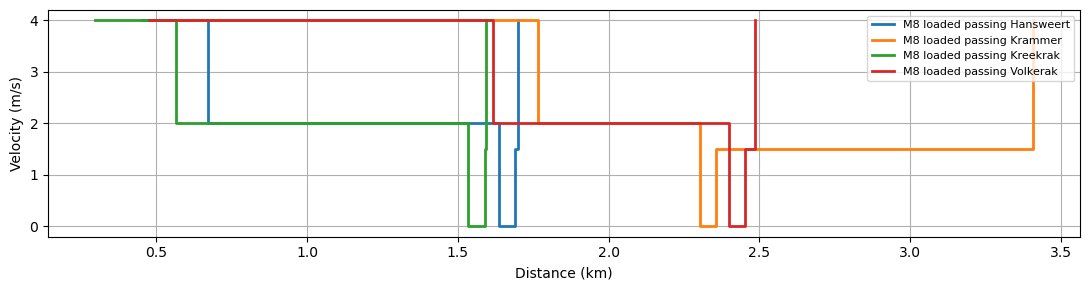

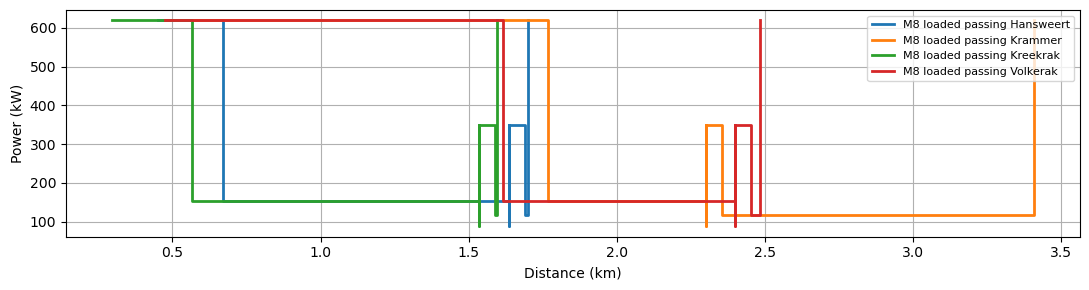

In [41]:
df = df_eventtable_energy_H2.copy()
df = df.sort_values("start time")

#Keep only LOADED vessels
# df = df[df["object name"].str.contains(" loaded")]

# # Keep only LOADED and 2 revelant ROUTES
# df = df[
#     df["object name"].str.contains(" loaded", na=False) &
#     (
#         df["object name"].str.contains("NM\\+ZB", na=False) |
#         df["object name"].str.contains("OM\\+SR", na=False)
#     )
# ]

# Prepare figure
fig, ax = plt.subplots(figsize=(11, 3))

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Group per route
for i, (route, g) in enumerate(df.groupby("object name")):

    g = g.copy()
    g["distance_cum_km"] = g["distance (m)"].cumsum() / 1000

    color = base_colors[i % len(base_colors)]

    ax.plot(
        g["distance_cum_km"],
        g["velocity (m/s)"],
        drawstyle="steps-post",
        linewidth=2,
        color=color,
        label=route
    )

ax.set_xlabel("Distance (km)")
ax.set_ylabel("Velocity (m/s)")
ax.grid(True)
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

# Copy & sort
df = df_eventtable_energy_H2.copy()
df = df.sort_values("start time")

# Keep only LOADED vessels
# df = df[df["object name"].str.contains(" loaded")]

# # Keep only LOADED and 2 revelant ROUTES
# df = df[
#     df["object name"].str.contains(" loaded", na=False) &
#     (
#         df["object name"].str.contains("NM\\+ZB", na=False) |
#         df["object name"].str.contains("OM\\+SR", na=False)
#     )
# ]

# Prepare figure
fig, ax = plt.subplots(figsize=(11, 3))

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Group per route
for i, (route, g) in enumerate(df.groupby("object name")):

    g = g.copy()
    g["distance_cum_km"] = g["distance (m)"].cumsum() / 1000

    color = base_colors[i % len(base_colors)]

    ax.plot(
        g["distance_cum_km"],
        g["P_given (kW)"],
        drawstyle="steps-post",
        # linestyle="--",
        linewidth=2,
        color=color,
        label=route
    )

ax.set_xlabel("Distance (km)")
ax.set_ylabel("Power (kW)")
ax.grid(True)
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()


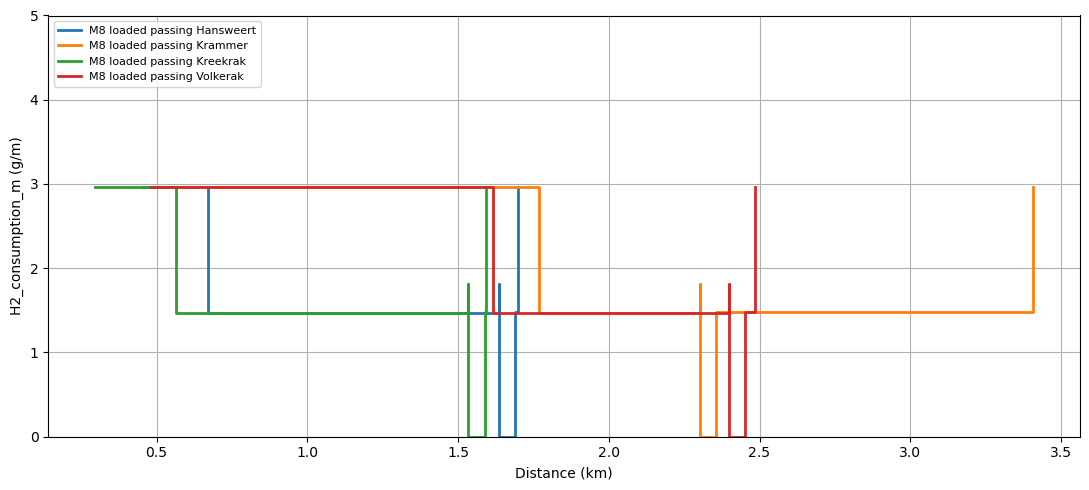

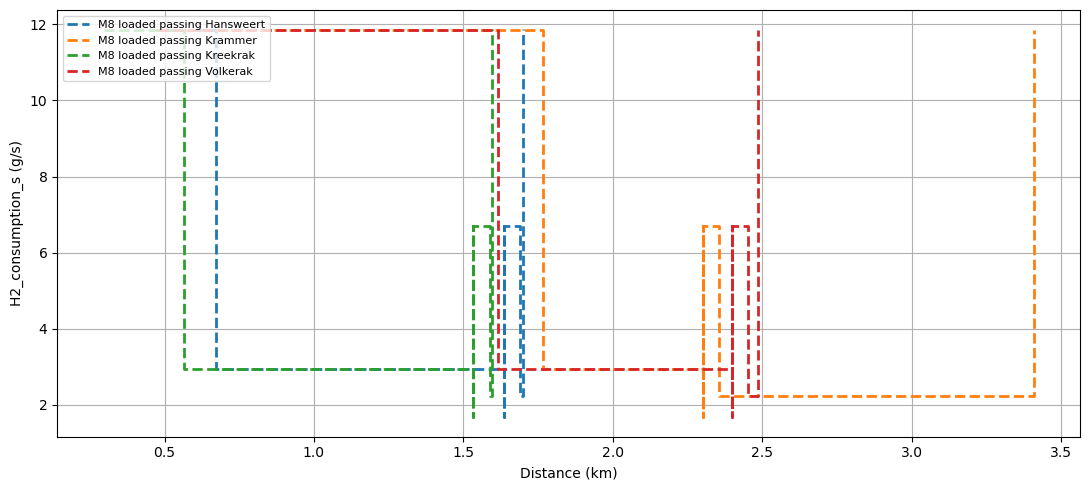

In [42]:
df = df_eventtable_energy_H2.copy()
df = df.sort_values("start time")

#Keep only LOADED vessels
# df = df[df["object name"].str.contains(" loaded")]

# Keep only LOADED and 2 revelant ROUTES
# df = df[
#     df["object name"].str.contains(" loaded", na=False) &
#     (
#         df["object name"].str.contains("NM\\+ZB", na=False) |
#         df["object name"].str.contains("OM\\+SR", na=False)
#     )
# ]


# Prepare figure
fig, ax = plt.subplots(figsize=(11, 5))

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Group per route
for i, (route, g) in enumerate(df.groupby("object name")):

    g = g.copy()
    g["distance_cum_km"] = g["distance (m)"].cumsum() / 1000

    color = base_colors[i % len(base_colors)]

    ax.plot(
        g["distance_cum_km"],
        g["H2_consumption_m (g/m)"],
        drawstyle="steps-post",
        # linestyle="--",
        linewidth=2,
        color=color,
        label=route
    )

ax.set_xlabel("Distance (km)")
ax.set_ylabel("H2_consumption_m (g/m)")
ax.set_ylim(0,5)
ax.grid(True)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

# Copy & sort
df = df_eventtable_energy_H2.copy()
df = df.sort_values("start time")

# Keep only LOADED vessels
# df = df[df["object name"].str.contains(" loaded")]

# Keep only LOADED and 2 revelant ROUTES
# df = df[
#     df["object name"].str.contains(" loaded", na=False) &
#     (
#         df["object name"].str.contains("NM\\+ZB", na=False) |
#         df["object name"].str.contains("OM\\+SR", na=False)
#     )
# ]

# Prepare figure
fig, ax = plt.subplots(figsize=(11, 5))

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Group per route
for i, (route, g) in enumerate(df.groupby("object name")):

    g = g.copy()
    g["distance_cum_km"] = g["distance (m)"].cumsum() / 1000

    color = base_colors[i % len(base_colors)]

    ax.plot(
        g["distance_cum_km"],
        g["H2_consumption_s (g/s)"],
        drawstyle="steps-post",
        linestyle="--",
        linewidth=2,
        color=color,
        label=route
    )

ax.set_xlabel("Distance (km)")
ax.set_ylabel("H2_consumption_s (g/s)")
ax.grid(True)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()


#### Trying to print speed and power over distance for the four locks

#### Multipyling with fleet

In [43]:
# # Insert count of vessels per route section 
# Nieuwe_Maas   = 232
# Oude_Maas     = 203
# Zuid_Beveland = 182
# Scheldt_Rhine = 271

# # Compute ratios 
# Ratio_NM   = Nieuwe_Maas/(Nieuwe_Maas + Oude_Maas)
# Ratio_OM   = Oude_Maas/(Nieuwe_Maas + Oude_Maas)
# Ratio_ZB   = Zuid_Beveland/(Zuid_Beveland + Scheldt_Rhine)
# Ratio_SR   = Scheldt_Rhine/(Zuid_Beveland + Scheldt_Rhine)

# # Insert loading ratio
# Ratio_loaded = 0.5
# Ratio_empty  = 1 - Ratio_loaded 

In [44]:
# # Insert total vessels 
# total_vessels = 250

# OM_SR_loaded  = total_vessels * Ratio_OM * Ratio_SR * Ratio_loaded
# OM_SR_empty   = total_vessels * Ratio_OM * Ratio_SR * Ratio_empty
# NM_SR_loaded  = total_vessels * Ratio_NM * Ratio_SR * Ratio_loaded
# NM_SR_empty   = total_vessels * Ratio_NM * Ratio_SR * Ratio_empty
# OM_ZB_loaded  = total_vessels * Ratio_OM * Ratio_ZB * Ratio_loaded
# OM_ZB_empty   = total_vessels * Ratio_OM * Ratio_ZB * Ratio_empty
# NM_ZB_loaded  = total_vessels * Ratio_NM * Ratio_ZB * Ratio_loaded
# NM_ZB_empty   = total_vessels * Ratio_NM * Ratio_ZB * Ratio_empty

# print("Computed route ratios ---")
# print(f"NM ratio (Nieuwe / Total Maas) : {Ratio_NM:.3f} ({Ratio_NM:.1%})")
# print(f"OM ratio (Oude / Total Maas)   : {Ratio_OM:.3f} ({Ratio_OM:.1%})")
# print(f"ZB ratio (Zuid Beveland)       : {Ratio_ZB:.3f} ({Ratio_ZB:.1%})")
# print(f"SR ratio (Scheldt–Rhine)       : {Ratio_SR:.3f} ({Ratio_SR:.1%})")

#### Fleet totals

In [45]:
# # Fleet definition
# fleet_map = {
#     "M8 loaded passing OM+SR": OM_SR_loaded,
#     # "M8 unloaded passing OM+SR": OM_SR_empty,
#     "M8 loaded passing NM+SR": NM_SR_loaded,
#     # "M8 unloaded passing NM+SR": NM_SR_empty,
#     "M8 loaded passing OM+ZB": OM_ZB_loaded,
#     # "M8 unloaded passing OM+ZB": OM_ZB_empty,
#     "M8 loaded passing NM+ZB": NM_ZB_loaded,
#     # "M8 unloaded passing NM+ZB": NM_ZB_empty,
# }

# # Build fleet totals table (per vessel values)
# summary_fleet_totals = (
#     summary
#     .loc[:, ['total_energy (kWh)', 'H2_consumption (kg)']]
#     .rename(columns={
#         'total_energy (kWh)': 'total_energy_vessel (kWh)',
#         'H2_consumption (kg)': 'H2_consumption_vessel (kg)'
#     })
# )

# # Add & round number of vessels BEFORE scaling
# summary_fleet_totals.insert(
#     0,
#     'number of vessels',
#     summary_fleet_totals.index.map(fleet_map).round(0).astype(int)
# )

# # Fleet totals
# summary_fleet_totals['total_energy_fleet (kWh)'] = (
#     summary_fleet_totals['total_energy_vessel (kWh)']
#     * summary_fleet_totals['number of vessels']
# )

# summary_fleet_totals['H2_consumption_fleet (kg)'] = (
#     summary_fleet_totals['H2_consumption_vessel (kg)']
#     * summary_fleet_totals['number of vessels']
# )

# # Add TOTAL FLEET row
# total_row = (
#     summary_fleet_totals
#     .sum()
#     .to_frame()
#     .T
# )
# total_row.index = ['TOTAL FLEET']

# summary_fleet_totals = pd.concat(
#     [summary_fleet_totals, total_row]
# ).round(2)

# summary_fleet_totals